[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 8 Discrete-Time Convolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

In [2]:
if True:
    h = np.array([2, 1, -1], dtype=int)
    kh_start = 0

    x = np.array([1, 1, 2, -1], dtype=int)
    kx_start = 1
else:
    h = np.array([1, 2, 3], dtype=int)
    kh_start = 1

    x = np.array([4, 5, 6, 7], dtype=int)
    kx_start = 4

In [3]:
kh = np.arange(len(h)) + kh_start
kx = np.arange(len(x)) + kx_start
ky_start = kx[0] + kh[0]
ky = np.arange(len(x) + len(h) - 1) + ky_start

y = np.convolve(x, h)

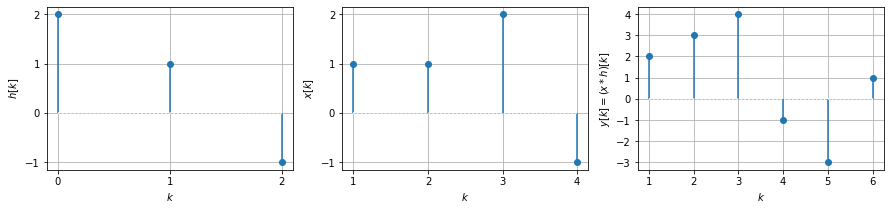

In [4]:
plt.figure(figsize=(15, 3))

ax = plt.subplot(1, 3, 1)
plt.stem(kh, h, use_line_collection=True,
         linefmt='C0-', markerfmt='C0o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.grid(True)

ax = plt.subplot(1, 3, 2)
plt.stem(kx, x, use_line_collection=True,
         linefmt='C0-', markerfmt='C0o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$x[k]$')
plt.grid(True)

ax = plt.subplot(1, 3, 3)
plt.stem(ky, y, use_line_collection=True,
         linefmt='C0-', markerfmt='C0o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$y[k] = (x * h)[k]$')
plt.grid(True)

## Toeplitz Matrix Approach 

In [5]:
toeplitz = np.zeros([len(x) + len(h) - 1, len(h)], dtype=int)
for i in range(len(h)):
    toeplitz[i:i+len(x), i] = x
print('arange x as toeplitz matrix')
print(toeplitz)
print('h as column')
print(h[:, np.newaxis])

# discrete convolution with
# - toeplitz storing shifted input signal x as cols
# - impulse response h used as weights for the linear combination
y1 = toeplitz @ h

# linear combination hard coded for our example
y2 = h[0] * toeplitz[:, 0] + h[1] * toeplitz[:, 1] + h[2] * toeplitz[:, 2]
print('y = x * h = toeplitz @ h as column')
print(y[:, np.newaxis])

# check the different approaches
print(np.allclose(y1, y))
print(np.allclose(y2, y))

arange x as toeplitz matrix
[[ 1  0  0]
 [ 1  1  0]
 [ 2  1  1]
 [-1  2  1]
 [ 0 -1  2]
 [ 0  0 -1]]
h as column
[[ 2]
 [ 1]
 [-1]]
y = x * h = toeplitz @ h as column
[[ 2]
 [ 3]
 [ 4]
 [-1]
 [-3]
 [ 1]]
True
True


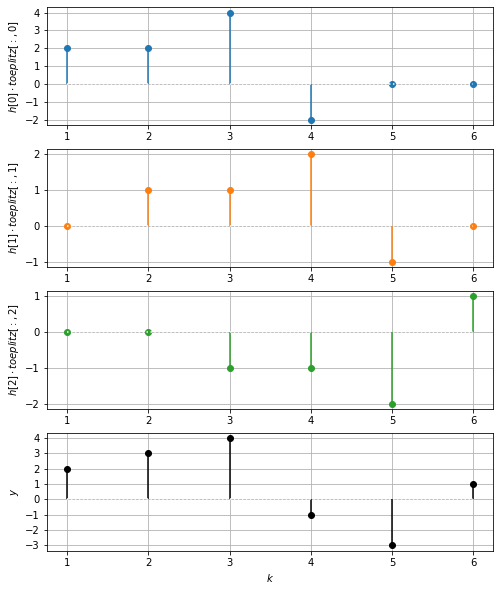

In [6]:
plt.figure(figsize=(8, 10))

ax = plt.subplot(4, 1, 1)
plt.stem(ky, h[0] * toeplitz[:,0], use_line_collection=True,
         linefmt='C0-', markerfmt='C0o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel(r'$h[0] \cdot toeplitz[:,0]$')
plt.grid(True)

ax = plt.subplot(4, 1, 2)
plt.stem(ky, h[1] * toeplitz[:,1], use_line_collection=True,
         linefmt='C1-', markerfmt='C1o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel(r'$h[1] \cdot toeplitz[:,1]$')
plt.grid(True)

ax = plt.subplot(4, 1, 3)
plt.stem(ky, h[2] * toeplitz[:,2], use_line_collection=True,
         linefmt='C2-', markerfmt='C2o', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel(r'$h[2] \cdot toeplitz[:,2]$')
plt.grid(True)

ax = plt.subplot(4, 1, 4)
plt.stem(ky, y, use_line_collection=True,
         linefmt='k-', markerfmt='ko', basefmt='w:')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel(r'$k$')
plt.ylabel(r'$y$')
plt.grid(True)

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.